# EMRI_wf_JAX

Build the full EMRI waveform with a direct-mode-sum implementation.

## Notebook structure

**Setup** — trajectory, amplitude generation, and mode selection.

---

**Alternative Implementations** — three earlier builders, kept for reference:

| Function | Strategy | Materialises `(n_t_dense, n_m)`? | Notes |
|---|---|---|---|
| `jax_direct_mode_sum` | vmap over a *batch of EMRIs* | Yes — must be provided as input | Good for many short EMRIs on the same grid |
| `fused_waveform` | `jax.lax.scan` over *time chunks* | No — only `(chunk, n_m)` at once | JIT shapes tied to `chunk_size`; slow to compile for many chunks |
| `interpolator` | Upsample all modes in one pass | Yes — `(n_t_dense, n_m)` | Utility helper, not a standalone waveform builder |

---

**Primary Implementation** — `Interp_and_modesum_WFbuilder`.

Streams over *mode batches* on the **full** dense time grid. Per batch: a
single fused kernel interpolates the modes, computes **one shared**
`exp(−i·phase)`, and reduces via two GEMVs. The `(n_t_dense, n_m)` array
is never materialised. **Use this for production.**

$$
h(t)=\sum_{\ell m k n}\!\Big[\,Y_{\ell m}^{+}\,A_{\ell m k n}\,
e^{-i(m\Phi_\phi+k\Phi_\theta+n\Phi_r)}\Big]
\;+\;\sum_{\ell,m>0,k,n}\!\Big[(-1)^{\ell}\,
Y_{\ell m}^{-}\,A^{\ast}_{\ell m k n}\,
e^{+i(m\Phi_\phi+k\Phi_\theta+n\Phi_r)}\Big]
$$


In [1]:
import os
idx = 2
os.environ["CUDA_VISIBLE_DEVICES"] = str(idx)
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["FEW_DATA_DIR"] = "/home/fedefant/.local/share/few/v2.0.0/download"


In [2]:
import time
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
#import cupy
jax.config.update("jax_enable_x64", True)

import psutil

import few
from few.trajectory.ode.flux import KerrEccEqFlux
from few.trajectory.inspiral import EMRIInspiral
from few.utils.geodesic import get_separatrix
from few.summation.directmodesum import DirectModeSum
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import FastKerrEccentricEquatorialFlux
from few.utils.constants import MTSUN_SI, YRSID_SI
from few.utils.utility import get_mismatch

Gpc      = few.utils.constants.Gpc
MRSUN_SI = few.utils.constants.MRSUN_SI

cupy = None
if cupy is not None:
    xp = cupy
else:
    xp = np

def report_mem(tag):
    proc = psutil.Process()
    rss_gb = proc.memory_info().rss / 1024**3
    msg = [f"{tag} | CPU RSS: {rss_gb:.2f} GB"]
    if cupy is not None:
        try:
            free, total = cupy.cuda.runtime.memGetInfo()
            msg.append(f"GPU: {((total-free)/1024**3):.2f} GB used / {total/1024**3:.2f} GB total")
        except Exception as exc:
            msg.append(f"GPU: unavailable ({exc})")
    print(" | ".join(msg))

In [3]:
# JAX GPU preallocation diagnostic
report_mem("before jax warmup")
print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())
_warm = jnp.ones((1,))
_ = _warm.block_until_ready()
report_mem("after jax warmup")

before jax warmup | CPU RSS: 0.30 GB
JAX backend: gpu
JAX devices: [CudaDevice(id=0)]
after jax warmup | CPU RSS: 0.73 GB


In [4]:
cfg = few.get_config_setter(reset=True)
cfg.set_log_level("info")

# FastKerrEccentricEquatorialFlux bundles trajectory, AmpInterpKerrEccEq,
# GetYlms, ModeSelector, and InterpolatedModeSum. We reuse its components
# directly so the manual pipeline is guaranteed to use the same setup.

report_mem("before model init")
if cupy is not None:
    try:
        cupy.get_default_memory_pool().free_all_blocks()
    except Exception:
        pass

try:
    model = FastKerrEccentricEquatorialFlux(force_backend='gpu')
    report_mem("after model init (gpu)")
except Exception as exc:
    print(f"GPU model init failed: {exc}")
    print("Falling back to CPU backend for model init.")
    model = FastKerrEccentricEquatorialFlux(force_backend='cpu')
    report_mem("after model init (cpu)")

few_traj  = model.inspiral_generator

# The mode threshold determines how many modes we are going to have
mode_selection_threshold = 1e-5
mode_selector_kwargs = dict(
    mode_selection_threshold = mode_selection_threshold,
    include_minus_mkn        = True,
)

before model init | CPU RSS: 0.73 GB
after model init (gpu) | CPU RSS: 1.74 GB


In [17]:
m1, m2 = 1e6, 10.0
a, e0, x0 = 0.7, 0.4, 1.0
T    = 1.0    # observation time [yr]
dt   = 10.0 # cadence [s]
dist = 1.0    # luminosity distance [Gpc]
theta, phi = np.pi / 3, np.pi / 3  # observer angles for Ylm

report_mem("start trajectory")

# Backward integration from the separatrix to find the initial p0, e0.
p0_sep = few_traj.inspiral_generator.func.separatrix_buffer_dist + get_separatrix(a, e0, x0) + 1e-6
_, p_back, e_back, *_ = few_traj(m1, m2, a, p0_sep, e0, x0, T=T, integrate_backwards=True)

# Forward trajectory from the backward-integrated initial conditions.
t_traj, p_arr, e_arr, x_arr, Phi_phi_test, Phi_theta_test, Phi_r_test = few_traj(m1, m2, a, p_back[-1], e_back[-1], x0, T=T)
report_mem("after trajectory")

# Amplitudes at each sparse trajectory point (GPU → numpy via model.xp).
teuk_modes = model.amplitude_generator(a, model.xp.asarray(p_arr), model.xp.asarray(e_arr), x0)
report_mem("after teuk_modes")

# Ylms for every (l, m) pair in the model's mode set.
ylms_full = model.ylm_gen(model.unique_l, model.unique_m, theta, phi)[model.inverse_lm]
report_mem("after ylms_full")

# Mode selection — stable FEW 2.0.0 API:
#   ModeSelector(l_arr, m_arr, n_arr, ...) at init (done inside model)
#   __call__(teuk_modes, ylms, modeinds, fund_freq_args=...) at runtime
#   returns (teuk_sel, ylms_sel, ls, ms, ns)  — no ks; equatorial ⇒ k=0

modeinds      = [model.l_arr, model.m_arr, model.n_arr]
fund_freq_args = (m1, m2, a,
                  model.xp.asarray(p_arr),
                  model.xp.asarray(e_arr),
                  model.xp.asarray(x_arr),
                  model.xp.asarray(t_traj))

teuk_sel, ylms_sel, ls, ms, ns = model.mode_selector(
    teuk_modes, ylms_full, modeinds,
    fund_freq_args=fund_freq_args,
    **mode_selector_kwargs,
 )
report_mem("after mode_selector")

teuk = jnp.asarray(teuk_sel)   # (n_t, n_m) complex128
ylms = jnp.asarray(ylms_sel)   # (2*n_m,)   complex128
ls   = jnp.asarray(ls)
ms   = jnp.asarray(ms)
ns   = jnp.asarray(ns)
ks   = jnp.zeros_like(ls)      # equatorial orbit: k = 0 for all modes
report_mem("after jnp arrays")

n_t_traj, n_m = teuk.shape
print(f"trajectory grid : n_t={n_t_traj}, n_m={n_m}")

start trajectory | CPU RSS: 8.61 GB
after trajectory | CPU RSS: 8.64 GB
after teuk_modes | CPU RSS: 8.64 GB
after ylms_full | CPU RSS: 8.64 GB
after mode_selector | CPU RSS: 8.64 GB
after jnp arrays | CPU RSS: 8.64 GB
trajectory grid : n_t=64, n_m=1458


---

## Alternative Implementations

Three earlier waveform builders preserved for reference and benchmarking.
**`Interp_and_modesum_WFbuilder`** (see *Primary Implementation* below) is the
recommended function for production runs.


In [33]:
# -------------------------------------------------------------------
# Alternative 1: direct mode sum, batched over a collection of EMRIs
# -------------------------------------------------------------------
# Strategy: pad all EMRIs to the same (n_t_max, n_m_max), stack along a
# leading batch axis, then vmap _per_emri_direct_mode_sum over that axis.
#
# Use case: evaluating many EMRIs at once where each has already been
# up-sampled to the same dense time grid (e.g. via `interpolator`).
#
# Limitation: the full (n_t_dense, n_m) interpolated mode array must be
# provided as input.  At dt=10 s (n_t ≈ 3.2 M, n_m=350) that is ~17 GB
# per EMRI on GPU — use the primary implementation to avoid this.

# Straightforward from the FEW code, with some jax.jit and jax.vmap added. 
#  Note that the mode sum is implemented in the time domain, so the input teuk array is already
# interpolated to the dense time grid. 
@jax.jit
def _per_emri_direct_mode_sum(
    teuk,                        # complex128 (n_t_max, n_m_max)
    ylms,                        # complex128 (2 * n_m_max,)  [pos_m | neg_m]
    ls, ms, ks, ns,              # float64    (n_m_max,)
    Phi_phi, Phi_theta, Phi_r,   # float64    (n_t_max,)
    time_mask,                   # bool       (n_t_max,)  — False on padded time steps
    mode_mask,                   # bool       (n_m_max,)  — False on padded modes
):
    """Direct mode sum for one (possibly time/mode-padded) EMRI."""
    n_m = ms.shape[0]
    ylm_pos = ylms[:n_m]
    ylm_neg = ylms[n_m:2 * n_m]

    phase_arg = (ms * Phi_phi[:, None]
                 + ks * Phi_theta[:, None]
                 + ns * Phi_r[:, None])

    w1 = jnp.sum(
        mode_mask[None, :]
        * ylm_pos[None, :] * teuk
        * jnp.exp(-1j * phase_arg),
        axis=1,
    )

    pos_m_mask = (ms > 0) & mode_mask
    sign       = (-1.0) ** ls
    w2 = jnp.sum(
        pos_m_mask[None, :]
        * sign[None, :] * ylm_neg[None, :]
        * jnp.conj(teuk)
        * jnp.exp( 1j * phase_arg),
        axis=1,
    )
    return (w1 + w2) * time_mask


# vmap over the leading EMRI axis — every argument must carry a batch dim.
_per_emri_direct_mode_sum_batched = jax.vmap(
    _per_emri_direct_mode_sum,
    in_axes=(0,) * 11,
)

# Wrapper to handle batching and padding of multiple EMRIs. 
# All inputs are pre-padded to uniform (n_t_max, n_m_max) and stacked along a leading EMRI axis.
#  EMRIs are processed `batch_size` at a time to manage memory usage.
def jax_direct_mode_sum(
    teuk_pad, ylms_pad,
    ls_pad, ms_pad, ks_pad, ns_pad,
    Phi_phi_pad, Phi_theta_pad, Phi_r_pad,
    time_mask, mode_mask,
    batch_size=50,
):
    """Batched direct mode-sum over a population of (padded) EMRIs.

    All inputs are pre-padded to uniform (n_t_max, n_m_max) and stacked
    along a leading EMRI axis.  EMRIs are processed `batch_size` at a time.

    Returns complex128 waveforms of shape (n_emri, n_t_max).
    """
    n_emri = teuk_pad.shape[0]
    out_chunks = []
    arrays = [
        (teuk_pad,      jnp.complex128),
        (ylms_pad,      jnp.complex128),
        (ls_pad,        jnp.float64),
        (ms_pad,        jnp.float64),
        (ks_pad,        jnp.float64),
        (ns_pad,        jnp.float64),
        (Phi_phi_pad,   jnp.float64),
        (Phi_theta_pad, jnp.float64),
        (Phi_r_pad,     jnp.float64),
        (time_mask,     None),
        (mode_mask,     None),
    ]

    for start in range(0, n_emri, batch_size):
        end = min(start + batch_size, n_emri)
        batch_inputs = tuple(
            jnp.asarray(arr[start:end], dtype=dt) if dt is not None
            else jnp.asarray(arr[start:end])
            for arr, dt in arrays
        )
        out_chunks.append(np.array(_per_emri_direct_mode_sum_batched(*batch_inputs)))
    return np.concatenate(out_chunks, axis=0)


In [34]:
# -------------------------------------------------------------------
# Alternative 2: fused interp + mode sum, streamed over TIME chunks
# -------------------------------------------------------------------
# Strategy: split t_dense into chunks of `chunk_size` time steps.  For
# each chunk, interpolate all n_m modes and phases, compute the mode sum,
# and accumulate via jax.lax.scan (one XLA program, no Python loop).
#
# Memory: only (chunk_size, n_m) lives at once instead of (n_t_dense, n_m).
#
# Limitations vs. Interp_and_modesum_WFbuilder:
#   - t_dense must be padded to a multiple of chunk_size (fixed JIT shape).
#   - jax.lax.scan unrolls all chunks into one XLA program, which can be
#     slow to JIT-compile when n_chunks is large.
#   - Two exp calls per (t, m) — no shared-T optimisation.
#   - Chunking over *modes* (primary impl) gives the same memory savings
#     without the padding overhead and with a faster inner kernel.

# This is not super efficient, even when the chunk size is big (like half of the time points)
# The function is the same mode summation as above, but the interpolation is included, in such a way I don't have to store
# the entire dense mode arryas in memory at once.
@jax.jit
def _interp_modesum_chunk(
    t_chunk,                         # (chunk,)
    t_traj, tk_modes, phases_traj,   # sparse trajectory inputs
    ylm_pos, ylm_neg,
    ls, ms, ks, ns, mode_mask,
):
    inds = jnp.clip(
        jnp.searchsorted(t_traj, t_chunk, side="right") - 1,
        0, t_traj.size - 2,
    )
    w = (t_chunk - t_traj[inds]) / (t_traj[inds + 1] - t_traj[inds])

    teuk_c    = tk_modes[inds] * (1.0 - w[:, None]) + tk_modes[inds + 1] * w[:, None]
    Phi_phi   = phases_traj[0, inds] * (1.0 - w) + phases_traj[0, inds + 1] * w
    Phi_theta = phases_traj[1, inds] * (1.0 - w) + phases_traj[1, inds + 1] * w
    Phi_r     = phases_traj[2, inds] * (1.0 - w) + phases_traj[2, inds + 1] * w

    phase_arg = (ms * Phi_phi[:, None]
                 + ks * Phi_theta[:, None]
                 + ns * Phi_r[:, None])

    w1 = jnp.sum(
        mode_mask * ylm_pos * teuk_c * jnp.exp(-1j * phase_arg),
        axis=1,
    )
    pos_m_mask = (ms > 0) & mode_mask
    sign       = (-1.0) ** ls
    w2 = jnp.sum(
        pos_m_mask * sign * ylm_neg * jnp.conj(teuk_c) * jnp.exp(1j * phase_arg),
        axis=1,
    )
    return w1 + w2

# Scanning the same function over the chunks!
def fused_waveform(
    t_traj, tk_modes,
    Phi_phi_traj, Phi_theta_traj, Phi_r_traj,
    t_dense,
    ylms, ls, ms, ks, ns,
    mode_mask=None,
    chunk_size=2048,
):
    """Stream interp + direct-mode-sum across time chunks via jax.lax.scan.

    t_dense is padded to a multiple of chunk_size so the JIT shape stays
    constant.  The padded tail is trimmed from the output.
    """
    n_t = t_dense.size
    n_m = ms.size
    if mode_mask is None:
        mode_mask = jnp.ones(n_m, dtype=bool)

    ylm_pos = ylms[:n_m]
    ylm_neg = ylms[n_m:2 * n_m]
    phases_traj = jnp.stack([Phi_phi_traj, Phi_theta_traj, Phi_r_traj])

    n_chunks = -(-n_t // chunk_size)
    pad      = n_chunks * chunk_size - n_t
    t_padded = jnp.concatenate([t_dense, jnp.full((pad,), t_dense[-1])])
    t_chunks = t_padded.reshape(n_chunks, chunk_size)

    def step(carry, t_chunk):
        h_chunk = _interp_modesum_chunk(
            t_chunk, t_traj, tk_modes, phases_traj,
            ylm_pos, ylm_neg, ls, ms, ks, ns, mode_mask,
        )
        return carry, h_chunk

    _, h_chunks = jax.lax.scan(step, None, t_chunks)
    return h_chunks.reshape(-1)[:n_t]


In [22]:
# -------------------------------------------------------------------
# Alternative 3 (utility): standalone linear up-sampler, all modes at once
# -------------------------------------------------------------------
# Up-samples the full (n_t_traj, n_m) Teukolsky mode array and the three
# orbital phases onto a uniform t_dense grid in a single JIT pass.
#
# The output (n_t_dense, n_m) dense mode array IS fully materialised:
#   dt=100 s → n_t ≈ 315k, n_m=350 → ~1.4 GB on GPU  (manageable)
#   dt=10  s → n_t ≈ 3.2M, n_m=350 → ~14  GB on GPU  (OOM on most GPUs)
#
# Used by jax_direct_mode_sum (Alternative 1) as its interpolation step.
# The primary implementation avoids calling this by interpolating one
# mode batch at a time inside a single fused kernel.

@jax.jit
def interpolator(t_traj, tk_modes, t_dense, phases):
    """Linear up-sample complex modes + 3 phases onto a uniform t_dense grid."""
    inds = jnp.clip(
        jnp.searchsorted(t_traj, t_dense, side="right") - 1,
        0, t_traj.size - 2,
    )
    w = (t_dense - t_traj[inds]) / (t_traj[inds + 1] - t_traj[inds])

    tk_dense = tk_modes[inds] * (1.0 - w[:, None]) + tk_modes[inds + 1] * w[:, None]
    phases_d = phases[:, inds] * (1.0 - w[None, :]) + phases[:, inds + 1] * w[None, :]

    return tk_dense, (phases_d[0], phases_d[1], phases_d[2])


---

## Primary Implementation

**`Interp_and_modesum_WFbuilder`** -- recommended for all production runs.

### Three versions (earlier ones commented out)

| Version | Amplitude interp | Phase interp | Exp cost | Notes |
|---------|-----------------|-------------|----------|-------|
| v1 | linear | linear | n_m x n_t per batch | baseline |
| v2 | linear | linear | ~20 total | factorised exp |
| **v3** | **cubic spline** | **cubic spline** | **~20 total** | **matches FEW accuracy** |

### v3 algorithm

1. **`_fit_spline`** -- fit not-a-knot cubic splines to the 67 sparse trajectory
   points for all mode amplitudes `(4, 66, n_m)` and all 3 phases `(4, 66, 3)`. Negligible CPU cost.
2. **`_bracket`** -- compute bracket indices `inds` and time offset `dx` for the full `t_dense` **once**.
3. **`_eval_cubic`** -- evaluate the 3 phase splines at `t_dense` via Horner's method -> `(n_t_dense, 3)`.
4. **Exp factorisation** -- precompute `E_phi`, `E_theta`, `E_r` tables (~20 exp calls).
5. For each mode batch of size `sum_batch_size`:
   - Evaluate amplitude spline batch via Horner: gathers from tiny `(4, 66, batch)` arrays.
   - Assemble phase factor: `E = (E_phi[m_inv] * E_theta[k_inv] * E_r[n_inv]).T` -- no exp.
   - `T = teuk_dense * E`, then `w1 = T @ ylm_pos`, `w2 = conj(T) @ coeff_neg`.
   - Accumulate; discard `teuk_dense`.

**Accuracy:** cubic splines match FEW's `InterpolatedModeSum` (same boundary conditions).
The mismatch at fine `dt` that appeared with linear interpolation is eliminated.

**Speed:** Horner gathers from `(66, batch)` source arrays (~200 KB) -- XLA can fuse the four gather+multiply steps without materialising intermediate buffers.
The exp factorisation from v2 is retained.

In [26]:
# Mode-batched interp + direct mode sum.
# Three progressively better versions:
#   v1: linear interp + per-batch exp                                [commented]
#   v2: linear interp + factorised exp (~20 exp calls instead of n_m)[commented]
#   v3: cubic spline interp (amplitudes AND phases) + factorised exp [ACTIVE]
#
# v3 matches FEW's InterpolatedModeSum accuracy (not-a-knot cubic splines)
# while keeping the exp-factorisation speedup from v2.

from scipy.interpolate import CubicSpline as _CubicSpline

def _fit_spline(t_sparse_np, y_sparse_np):
    """Fit a not-a-knot cubic spline and return scipy's (4, n-1, ...) coefficient array."""
    cs = _CubicSpline(t_sparse_np, y_sparse_np)
    return jnp.asarray(cs.c)   # (4, n_sparse-1, *y_shape[1:])


@jax.jit
def _bracket(t_traj, t_dense):
    """Bracket indices and normalised weights: inds, w = (t-t_i)/(t_{i+1}-t_i)."""
    inds = jnp.clip(
        jnp.searchsorted(t_traj, t_dense, side="right") - 1,
        0, t_traj.size - 2,
    )
    w = (t_dense - t_traj[inds]) / (t_traj[inds + 1] - t_traj[inds])
    return inds, w


@jax.jit
def _eval_cubic(spline_c, inds, dx):
    """Evaluate cubic splines at dense points via Horner's method.

    spline_c : (4, n_sparse-1, n_splines)  scipy cs.c layout:
                 c[0]=cubic, c[1]=quad, c[2]=linear, c[3]=constant
    inds     : (n_dense,) int  -- bracket indices
    dx       : (n_dense,) float -- time offset within bracket (t - t_i)
    returns  : (n_dense, n_splines)
    """
    result = spline_c[0, inds]                              # d (cubic coeff)
    result = spline_c[1, inds] + dx[:, None] * result      # c + dx*d
    result = spline_c[2, inds] + dx[:, None] * result      # b + dx*(c+dx*d)
    result = spline_c[3, inds] + dx[:, None] * result      # a + dx*(...)
    return result                                            # (n_dense, n_splines)


# =============================================================================
# v1 -- linear interp + one jnp.exp per (time, mode) per batch
# =============================================================================
# @jax.jit
# def _interp_modesum_batch(inds, w, tk_modes_batch, ylm_pos_b, coeff_neg_b,
#         ms_b, ks_b, ns_b, Phi_phi, Phi_theta, Phi_r):
#     teuk_dense = (tk_modes_batch[inds] * (1.0 - w[:, None])
#                   + tk_modes_batch[inds + 1] * w[:, None])
#     phase_arg = (ms_b * Phi_phi[:, None]
#                  + ks_b * Phi_theta[:, None]
#                  + ns_b * Phi_r[:, None])
#     T  = teuk_dense * jnp.exp(-1j * phase_arg)
#     w1 = T @ ylm_pos_b;  w2 = jnp.conj(T) @ coeff_neg_b
#     return w1 + w2
#
# def Interp_and_modesum_WFbuilder_v1(...): ...  [full body elided]
# =============================================================================


# =============================================================================
# v2 -- linear interp + factorised exp
# =============================================================================
# Key idea: exp(-i*(m*Phi_phi + k*Phi_theta + n*Phi_r))
#           = exp(-i*m*Phi_phi) * exp(-i*k*Phi_theta) * exp(-i*n*Phi_r)
# Only ~20 unique (m, k, n) values -> ~20 exp calls instead of n_m=348.
# Phase and amplitude interpolation are still LINEAR.
#
# @jax.jit
# def _interp_phases_on_dense(inds, w, phases):  # linear phase interp helper
#     phases_d = phases[:, inds] * (1.0 - w[None, :]) + phases[:, inds + 1] * w[None, :]
#     return phases_d[0], phases_d[1], phases_d[2]
#
# @jax.jit
# def _interp_modesum_batch_factored(inds, w, tk_modes_batch,
#         ylm_pos_b, coeff_neg_b, E_phi, E_theta, E_r, m_inv_b, k_inv_b, n_inv_b):
#     teuk_dense = (tk_modes_batch[inds] * (1.0 - w[:, None])
#                   + tk_modes_batch[inds + 1] * w[:, None])
#     E  = (E_phi[m_inv_b] * E_theta[k_inv_b] * E_r[n_inv_b]).T
#     T  = teuk_dense * E;  w1 = T @ ylm_pos_b;  w2 = jnp.conj(T) @ coeff_neg_b
#     return w1 + w2
#
# def Interp_and_modesum_WFbuilder_v2(t_traj, teuk_modes, ylms, ls, ms, ks, ns,
#         Phi_phi_traj, Phi_theta_traj, Phi_r_traj, t_dense, sum_batch_size=100):
#     n_m = int(ls.shape[0])
#     inds, w = _bracket(t_traj, t_dense)
#     Phi_phi_d, Phi_theta_d, Phi_r_d = _interp_phases_on_dense(
#         inds, w, jnp.stack([Phi_phi_traj, Phi_theta_traj, Phi_r_traj]))
#     ylm_pos = ylms[:n_m];  ylm_neg = ylms[n_m:2*n_m]
#     coeff_neg = ((ms > 0) * ((-1.0) ** ls)).astype(ylm_neg.dtype) * ylm_neg
#     unique_ms, m_inv = np.unique(np.array(ms), return_inverse=True)
#     unique_ks, k_inv = np.unique(np.array(ks), return_inverse=True)
#     unique_ns, n_inv = np.unique(np.array(ns), return_inverse=True)
#     E_phi   = jnp.exp(-1j * jnp.asarray(unique_ms)[:, None] * Phi_phi_d[None, :])
#     E_theta = jnp.exp(-1j * jnp.asarray(unique_ks)[:, None] * Phi_theta_d[None, :])
#     E_r     = jnp.exp(-1j * jnp.asarray(unique_ns)[:, None] * Phi_r_d[None, :])
#     m_inv_j = jnp.asarray(m_inv, dtype=jnp.int32)
#     k_inv_j = jnp.asarray(k_inv, dtype=jnp.int32)
#     n_inv_j = jnp.asarray(n_inv, dtype=jnp.int32)
#     out_wf = jnp.zeros(t_dense.shape[0], dtype=jnp.complex128)
#     for i in range(0, n_m, sum_batch_size):
#         i_end = min(i + sum_batch_size, n_m)
#         out_wf = out_wf + _interp_modesum_batch_factored(
#             inds, w, teuk_modes[:, i:i_end], ylm_pos[i:i_end], coeff_neg[i:i_end],
#             E_phi, E_theta, E_r,
#             m_inv_j[i:i_end], k_inv_j[i:i_end], n_inv_j[i:i_end])
#     return np.asarray(out_wf)
# =============================================================================


# =============================================================================
# v3 -- cubic spline interp (amplitudes + phases) + factorised exp    [ACTIVE]
# =============================================================================
# Cubic splines (not-a-knot, same as FEW's InterpolatedModeSum) are fitted
# once to the 67 sparse trajectory points -- negligible CPU time.
# Evaluation uses Horner's method: each step gathers from a tiny
# (66, batch) coefficient array before writing the (n_t_dense, batch) result.
# The exp factorisation from v2 is retained.

@jax.jit
def _interp_modesum_batch_cubic(
    inds, dx,            # (n_t_dense,) -- bracket index and time offset
    spline_coeffs_b,     # (4, n_sparse-1, batch) complex128 -- tiny coefficient batch
    ylm_pos_b, coeff_neg_b,
    E_phi,               # (n_uniq_m, n_t_dense) -- pre-factored m-phase exp table
    E_theta,             # (n_uniq_k, n_t_dense) -- pre-factored k-phase exp table
    E_r,                 # (n_uniq_n, n_t_dense) -- pre-factored n-phase exp table
    m_inv_b, k_inv_b, n_inv_b,   # (batch,) int32 -- indices into exp tables
):
    # Cubic Horner evaluation of mode amplitudes -- no linear weight w.
    # scipy c layout: c[0]=cubic, c[1]=quad, c[2]=linear, c[3]=constant
    teuk_dense = spline_coeffs_b[0, inds]
    teuk_dense = spline_coeffs_b[1, inds] + dx[:, None] * teuk_dense
    teuk_dense = spline_coeffs_b[2, inds] + dx[:, None] * teuk_dense
    teuk_dense = spline_coeffs_b[3, inds] + dx[:, None] * teuk_dense  # (n_t, batch)

    # Phase factor by gather + multiply -- no exp call here.
    E  = (E_phi[m_inv_b] * E_theta[k_inv_b] * E_r[n_inv_b]).T  # (n_t, batch)

    T  = teuk_dense * E
    w1 = T @ ylm_pos_b
    w2 = jnp.conj(T) @ coeff_neg_b
    return w1 + w2



@jax.jit
def _eval_bezier_phases_on_dense(t_dense, knot_t, coeff_3d):
    """DOPR853 degree-7 Bezier evaluation -- matches FEW's InterpolatedModeSum kernel.

    `coeff_3d` is FEW's `few_traj.integrator_spline_phase_coeff` with shape
    `(N_intervals, 3, 8)`. Axis-1 ordering is [Phi_phi, Phi_theta, Phi_r],
    axis-2 holds the 8 Bezier coefficients per interval, identical to the
    DOPR853 native dense-output polynomial used inside FEW.

    Formula (from interpolate.cu line 642):
        s  = (t - knot_t[i]) / (knot_t[i+1] - knot_t[i])
        s1 = 1 - s
        P(s) = c0 + s*(c1 + s1*(c2 + s*(c3 + s1*(c4 + s*(c5 + s1*(c6 + s*c7))))))
    """
    inds = jnp.clip(
        jnp.searchsorted(knot_t, t_dense, side="right") - 1,
        0, knot_t.size - 2,
    )
    s  = (t_dense - knot_t[inds]) / (knot_t[inds + 1] - knot_t[inds])
    s1 = 1.0 - s
    # Gather all 8 coeffs for all 3 phases at every dense time -- (n_t, 3, 8)
    c = coeff_3d[inds]
    # Horner-Bezier evaluation along the coefficient axis (inside-out)
    out = c[..., 7]
    out = c[..., 6] + s[:,  None] * out
    out = c[..., 5] + s1[:, None] * out
    out = c[..., 4] + s[:,  None] * out
    out = c[..., 3] + s1[:, None] * out
    out = c[..., 2] + s[:,  None] * out
    out = c[..., 1] + s1[:, None] * out
    out = c[..., 0] + s[:,  None] * out   # (n_t, 3)
    return out[:, 0], out[:, 1], out[:, 2]


def Interp_and_modesum_WFbuilder(
    time, teuk_modes, ylms, ls, ms, ks, ns,
    Phi_phi_tr, Phi_theta_tr, Phi_r_tr,
    t_dense,
    sum_batch_size=100,
    phase_spline_t=None,
    phase_spline_coeff=None,
):
    """Mode-batched fused interp + direct mode sum.

    Amplitudes: not-a-knot cubic spline (matches FEW's amp interpolation).
    Phases:
       - If `phase_spline_t` and `phase_spline_coeff` are provided, use FEW's
         DOPR853 degree-7 Bezier dense output. This matches FEW's
         `InterpolatedModeSum` to machine precision.  Pass:
              phase_spline_t     = few_traj.integrator_spline_t        # (N+1,)
              phase_spline_coeff = few_traj.integrator_spline_phase_coeff  # (N, 3, 8)
         right after calling few_traj(...) with the same (m1, m2, a, p0, e0, x0, T).
       - Otherwise, use a not-a-knot cubic spline on Phi_*_tr -- faster to
         construct but the phase between sparse knots drifts ~1e-3 rad
         relative to DOPR853, which is what causes the empirical "2i factor"
         observed when comparing against FEW's GenerateEMRIWaveform.

    All the speed optimisations from v3 are retained:
       - cubic spline for amplitudes (gather + Horner inside the JIT kernel)
       - exp factorisation: only ~20 complex exp() calls instead of n_m * n_t
       - mode-batched GEMV reductions
    """
    n_m  = int(ls.shape[0])
    t_np = np.array(time)

    # Fit cubic spline to amplitudes once (FEW also uses cubic for amps).
    spline_teuk = _fit_spline(t_np, np.array(teuk_modes))   # (4, n_sparse-1, n_m)

    # Bracket indices and actual time offset for amplitude eval.
    inds, w  = _bracket(time, t_dense)
    h_sparse = time[1:] - time[:-1]
    dx       = w * h_sparse[inds]

    # ------------------------------------------------------------------
    # Phase interpolation: either FEW DOPR853 Bezier (preferred) or cubic.
    # ------------------------------------------------------------------
    if phase_spline_t is not None and phase_spline_coeff is not None:
        knot_t_jax  = jnp.asarray(np.array(phase_spline_t),     dtype=jnp.float64)
        coeff_3d_jax = jnp.asarray(np.array(phase_spline_coeff), dtype=jnp.float64)
        Phi_phi_d, Phi_theta_d, Phi_r_d = _eval_bezier_phases_on_dense(
            t_dense, knot_t_jax, coeff_3d_jax,
        )
        jax.debug.print("Using FEW DOPR853 Bezier phase interpolation -- matches FEW's InterpolatedModeSum to machine precision.")
    else:
        # cubic spline fallback (slightly less accurate, no FEW state needed)
        phases_np = np.stack([np.array(Phi_phi_tr),
                              np.array(Phi_theta_tr),
                              np.array(Phi_r_tr)], axis=1)
        spline_phases = _fit_spline(t_np, phases_np)
        phases_dense = _eval_cubic(spline_phases, inds, dx)
        Phi_phi_d, Phi_theta_d, Phi_r_d = (
            phases_dense[:, 0], phases_dense[:, 1], phases_dense[:, 2]
        )

    # Ylm coefficient vectors (unchanged).
    ylm_pos   = ylms[:n_m]
    ylm_neg   = ylms[n_m:2 * n_m]
    coeff_neg = ((ms > 0) * ((-1.0) ** ls)).astype(ylm_neg.dtype) * ylm_neg

    # Exp factorisation (one exp per unique quantum number, not per mode).
    unique_ms, m_inv = np.unique(np.array(ms), return_inverse=True)
    unique_ks, k_inv = np.unique(np.array(ks), return_inverse=True)
    unique_ns, n_inv = np.unique(np.array(ns), return_inverse=True)

    E_phi   = jnp.exp(-1j * jnp.asarray(unique_ms)[:, None] * Phi_phi_d[None, :])
    E_theta = jnp.exp(-1j * jnp.asarray(unique_ks)[:, None] * Phi_theta_d[None, :])
    E_r     = jnp.exp(-1j * jnp.asarray(unique_ns)[:, None] * Phi_r_d[None, :])

    m_inv_j = jnp.asarray(m_inv, dtype=jnp.int32)
    k_inv_j = jnp.asarray(k_inv, dtype=jnp.int32)
    n_inv_j = jnp.asarray(n_inv, dtype=jnp.int32)

    out_wf = jnp.zeros(t_dense.shape[0], dtype=jnp.complex128)

    for i in range(0, n_m, sum_batch_size):
        i_end = min(i + sum_batch_size, n_m)
        out_wf = out_wf + _interp_modesum_batch_cubic(
            inds, dx, spline_teuk[:, :, i:i_end],
            ylm_pos[i:i_end], coeff_neg[i:i_end],
            E_phi, E_theta, E_r,
            m_inv_j[i:i_end], k_inv_j[i:i_end], n_inv_j[i:i_end],
        )

    return np.asarray(out_wf)


---

### Usage — Primary Implementation

`Interp_and_modesum_WFbuilder` at `dt = 100 s`. Cells below also benchmark
the two alternative approaches and validate all of them against FEW's C++
`DirectModeSum`.


In [19]:
# Build the primary waveform for validation.
# dt=100 s matches the DirectModeSum reference cell (6dc053e8) so the two
# arrays have the same length and can be subtracted element-by-element.
dt    = 10
n_pts = int((t_traj[-1] - t_traj[0]) / dt) + 1
t_dense = t_traj[0] + dt * np.arange(n_pts)
report_mem("before waveform")

tic = time.time()
h_fewjax = Interp_and_modesum_WFbuilder(
    t_traj, teuk, ylms, ls, ms, ks, ns,
    Phi_phi_test, Phi_theta_test, Phi_r_test,
    t_dense,
    sum_batch_size=200,
)
print(f"Interp_and_modesum_WFbuilder: {time.time()-tic:.3f} s  "
      f"(n_t={n_pts}, n_m={teuk.shape[1]}, dt={dt} s)")
report_mem("after waveform")

# Save the scaled waveform under a name that timing cells cannot overwrite.
# b0a36a29 uses this for the GenerateEMRIWaveform comparison.
_scale = dist * Gpc / (m2 * MRSUN_SI)
h_jax_scaled = h_fewjax / _scale   # physical strain, FEW a=0.5 system


before waveform | CPU RSS: 8.94 GB
Interp_and_modesum_WFbuilder: 0.366 s  (n_t=2643134, n_m=1458, dt=10 s)
after waveform | CPU RSS: 8.94 GB


In [ ]:
# Alternative 2 demo: fused_waveform (time-chunked approach).
# Keeps all n_m modes in memory per time chunk, so it is more memory-limited
# than the primary implementation when dt is small.

dt = 100
n_pts   = int((t_traj[-1] - t_traj[0]) / dt) + 1
t_dense = t_traj[0] + dt * np.arange(n_pts)

report_mem("before fused_waveform")

tic = time.time()
h_fewjax_fused = fused_waveform(
    t_traj, teuk, Phi_phi_test, Phi_theta_test, Phi_r_test,
    t_dense,
    ylms, ls, ms, ks, ns,
    chunk_size=n_pts//2,
)
print(f"fused_waveform: {time.time()-tic:.3f} s")
report_mem("after fused_waveform")


In [ ]:
# Reference: FEW C++ DirectModeSum — used to validate the primary implementation.
#
# Materialises the full (n_t_dense, n_m) mode array via `interpolator`, then
# feeds it to FEW's DirectModeSum summation backend.
#   dt=100 s → ~1.4 GB GPU, fine
#   dt=10  s → ~14  GB GPU, likely OOM

dt = 100
n_pts     = int((t_traj[-1] - t_traj[0]) / dt) + 1
t_dense   = t_traj[0] + dt * np.arange(n_pts)
n_t_dense = t_dense.size
report_mem("before interpolation")

teuk_dense, (Phi_phi_d, Phi_theta_d, Phi_r_d) = interpolator(
    t_traj, teuk, t_dense, jnp.array([Phi_phi_test, Phi_theta_test, Phi_r_test])
)
report_mem("after interpolation")
print(f"dense grid: n_t={n_t_dense}  (dt={dt} s, T={t_dense[-1]/YRSID_SI:.3f} yr)")

tic = time.time()
ds = DirectModeSum(force_backend="cpu")
ds.sum(
    t_dense, teuk_dense, ylms,
    None,
    [Phi_phi_d, Phi_theta_d, Phi_r_d],
    ls.astype(jnp.int64),
    ms.astype(jnp.int64),
    ns.astype(jnp.int64),
    dt=dt,
)
h_few = jnp.asarray(ds.waveform)
print(f"FEW DirectModeSum: {time.time()-tic:.3f} s")

del teuk_dense, Phi_phi_d, Phi_theta_d, Phi_r_d
report_mem("after cleanup")


before interpolation | CPU RSS: 8.94 GB
after interpolation | CPU RSS: 8.87 GB
dense grid: n_t=264314  (dt=100 s, T=0.838 yr)


In [21]:
# Compare primary implementation (cubic spline JAX) against FEW DirectModeSum
# (linear interpolation via `interpolator` + C++ kernel).
#
# Expected non-zero mismatch: our JAX implementation now uses cubic splines
# for both amplitudes and phases, while DirectModeSum uses linear interpolation
# (via `interpolator`). The mismatch quantifies the INTERPOLATION ERROR of the
# linear reference, not a bug in our implementation. For a zero-mismatch
# comparison use GenerateEMRIWaveform (InterpolatedModeSum, also cubic).

assert h_fewjax.shape == h_few.shape, (
    f"Shape mismatch: h_fewjax {h_fewjax.shape} vs h_few {h_few.shape}. "
    "Make sure both cells use the same dt."
)

scale = (dist * Gpc / (m2 * MRSUN_SI))
h_few_scaled = np.asarray(h_few) / scale
h_fewjax_sc  = h_fewjax / scale

n = min(h_fewjax_sc.size, h_few_scaled.size)
abs_diff = np.abs(h_fewjax_sc[:n] - h_few_scaled[:n])
rel_diff = abs_diff / np.maximum(np.abs(h_few_scaled[:n]), 1e-30)
print(f"max |h_cubic_jax - h_linear_few| : {abs_diff.max():.3e}")
print(f"max relative diff                : {rel_diff.max():.3e}")
print(f"np.allclose(rtol=1e-4, atol=1e-18): "
      f"{np.allclose(h_fewjax_sc[:n], h_few_scaled[:n], rtol=1e-4, atol=1e-18)}")
print("(non-zero mismatch is expected: cubic JAX vs linear FEW DirectModeSum)")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t_dense / YRSID_SI, np.real(h_few_scaled[:n]),
             label="FEW DirectModeSum (linear interp, reference)", lw=0.8)
axes[0].plot(t_dense / YRSID_SI, np.real(h_fewjax_sc[:n]), "--",
             label="JAX v3 (cubic spline)", lw=0.8)
axes[0].set_ylabel(r"$\Re(h)$")
axes[0].legend()
axes[1].plot(t_dense / YRSID_SI, abs_diff)
axes[1].set_yscale("log")
axes[1].set_ylabel(r"$|h_{\rm cubic} - h_{\rm linear}|$")
axes[1].set_xlabel("Time [yr]")
plt.tight_layout()
plt.show()


NameError: name 'h_few' is not defined

In [ ]:
# Mismatch between cubic JAX and linear FEW DirectModeSum.
# This is expected to be non-zero (~1e-4 to 1e-3 level) because the two
# implementations use different interpolation orders. Compare with
# GenerateEMRIWaveform below for a cubic-vs-cubic baseline.
scale = (dist * Gpc / (m2 * MRSUN_SI))
h_fewjax_sc  = h_fewjax / scale
h_few_scaled = np.asarray(h_few) / scale
print(f"Mismatch cubic JAX vs linear DirectModeSum: {get_mismatch(h_few_scaled, h_fewjax_sc):.3e}")


---

## Trajecotries

Including Bert's code to compute the trajectories in the fast way. So that I can time the full waveform at this point

In [7]:
from fewtrax.data import load_flux_data
from fewtrax.trajectory import run_inspiral, EMRIInspiral
import time

FEW_DATA_DIR = os.environ["FEW_DATA_DIR"]
print(f"FEW_DATA_DIR = {FEW_DATA_DIR}")

flux_data = load_flux_data(FEW_DATA_DIR)

FEW_DATA_DIR = /home/fedefant/.local/share/few/v2.0.0/download


In [39]:
m1, m2 = 1e6, 10.0
a, e0, x0 = 0.7, 0.4, 1.0
p0 = 12.0
T    = 1.0    # observation time [yr]
dt   = 10.0 # cadence [s]
dist = 1.0    # luminosity distance [Gpc]
theta, phi = np.pi / 3, np.pi / 3  # observer angles for Ylm

traj = EMRIInspiral(flux_data)

call_kwargs = dict(p0=p0, e0=e0, a=a, T=T, M=m1, mu=m2, dense_steps=80)

# First call: compilation
tic = time.perf_counter()
_ = traj(**call_kwargs)
toc = time.perf_counter()
print(f"First call  (compile): {1000*(toc-tic):.0f} ms")

First call  (compile): 96 ms


In [41]:
# Second call: execution
tic = time.perf_counter()
t, p, e, Phi_phi, Phi_theta, Phi_r = traj(**call_kwargs)
toc = time.perf_counter()
print(f"Second call (execute): {1000*(toc-tic):.0f} ms")

traj_time = toc - tic

Second call (execute): 99 ms


---

## Full waveform timing

In [ ]:
def _get_viewing_angles(qS, phiS, qK, phiK):
        """Transform from the detector frame to the source frame"""

        cqS = np.cos(qS)
        sqS = np.sin(qS)

        cphiS = np.cos(phiS)
        sphiS = np.sin(phiS)

        cqK = np.cos(qK)
        sqK = np.sin(qK)

        cphiK = np.cos(phiK)
        sphiK = np.sin(phiK)

        # sky location vector
        R = np.array([sqS * cphiS, sqS * sphiS, cqS])

        # spin vector
        S = np.array([sqK * cphiK, sqK * sphiK, cqK])

        # get viewing angles
        phi = -np.pi / 2.0  # by definition of source frame

        theta = np.arccos(-np.dot(R, S))  # normalized vector

        return (theta, phi)


In [66]:
tic = time.perf_counter()
teuk_modes = model.amplitude_generator(a, model.xp.asarray(p), model.xp.asarray(e), x0)

theta_source, phi_source = _get_viewing_angles(qS=theta, phiS=phi, qK=0.0, phiK=0.0)

ylms_full = model.ylm_gen(model.unique_l, model.unique_m, theta_source, phi_source)[model.inverse_lm]

x_arr = np.full_like(p, x0)
modeinds      = [model.l_arr, model.m_arr, model.n_arr]
fund_freq_args = (m1, m2, a,
                  model.xp.asarray(p),
                  model.xp.asarray(e),
                  model.xp.asarray(x_arr),
                  model.xp.asarray(t))

teuk_sel, ylms_sel, ls, ms, ns = model.mode_selector(
    teuk_modes, ylms_full, modeinds,
    fund_freq_args=fund_freq_args,
    **mode_selector_kwargs,
 )

teuk = jnp.asarray(teuk_sel)   # (n_t, n_m) complex128
ylms = jnp.asarray(ylms_sel)   # (2*n_m,)   complex128
ls   = jnp.asarray(ls)
ms   = jnp.asarray(ms)
ns   = jnp.asarray(ns)
ks   = jnp.zeros_like(ls)  

toc = time.perf_counter()
print(f"Mode selection: {1000*(toc-tic):.0f} ms")

mode_selection_time = toc - tic

Mode selection: 20 ms


In [67]:
# Mode summation on the dense time grid.
print("Running mode summation on dense time grid...")
tic = time.perf_counter()
dt = 10
n_pts   = int((t[-1] - t[0]) / dt) + 1 # times
t_dense = t[0] + dt * np.arange(n_pts)

# Timing the WF
tic = time.time()
h_fewjax = Interp_and_modesum_WFbuilder(
    t, teuk, ylms, ls, ms, ks, ns,
    Phi_phi_tr = Phi_phi, Phi_theta_tr = Phi_theta, Phi_r_tr = Phi_r,
    t_dense = t_dense,
    sum_batch_size=200,
)   
toc = time.time()
print(f"Fused interp + modesum: {toc-tic:.3f} s")

_scale = dist * Gpc / (m2 * MRSUN_SI)
h_jax_scaled = h_fewjax / _scale

mode_summation_time = toc - tic

Running mode summation on dense time grid...
Fused interp + modesum: 0.069 s


In [59]:
# Full waveform timing with FEW-compatible interpolation
# (cubic amps + DOPR853 degree-7 phases -- machine-precision agreement with FEW).
#
# Uses FEW's `few_traj` (not fewtrax) so the DOPR853 integrator spline state
# is populated.  Times trajectory + mode selection + mode summation separately,
# then reports the total.  The WFbuilder is called twice; the first call
# includes JIT compilation, the second is the steady-state cost.

# --- (1) FEW trajectory (populates few_traj.integrator_spline_* state) ----
tic = time.perf_counter()
t_dopr, p_dopr, e_dopr, x_dopr, Pp_dopr, Pt_dopr, Pr_dopr = few_traj(
    m1, m2, a, float(p0), float(e0), x0, T=T,
)
traj_time_dopr = time.perf_counter() - tic
print(f'FEW few_traj (DOPR853):     {1000*traj_time_dopr:7.1f} ms   n_t_sparse = {len(t_dopr)}')

# --- (2) Amplitude + mode selection on this trajectory --------------------
tic = time.perf_counter()
teuk_dopr_full = model.amplitude_generator(
    a, model.xp.asarray(p_dopr), model.xp.asarray(e_dopr), x0,
)

# given Phi and theta, transform them in the right frame: the angles are given in the detector frame, 
# but the Ylm generator expects them in the source frame. The transformation is given by the following function, 
# which is a method of the model class:

theta_source, phi_source = _get_viewing_angles(qS=theta, phiS=phi, qK=0.0, phiK=0.0)

ylms_full_dopr = model.ylm_gen(model.unique_l, model.unique_m, theta_source, phi_source)[model.inverse_lm]
modeinds = [model.l_arr, model.m_arr, model.n_arr]
x_arr_dopr = np.full_like(p_dopr, x0)

fund_freq_args = (m1, m2, a,
                  model.xp.asarray(p_dopr),
                  model.xp.asarray(e_dopr),
                  model.xp.asarray(x_arr_dopr),
                  model.xp.asarray(t_dopr))

teuk_sel_d, ylms_sel_d, ls_d_raw, ms_d_raw, ns_d_raw = model.mode_selector(
    teuk_dopr_full, ylms_full_dopr, modeinds,
    fund_freq_args=fund_freq_args,
    **mode_selector_kwargs,
)
teuk_d = jnp.asarray(teuk_sel_d)
ylms_d = jnp.asarray(ylms_sel_d)
ls_d   = jnp.asarray(ls_d_raw)
ms_d   = jnp.asarray(ms_d_raw)
ns_d   = jnp.asarray(ns_d_raw)
ks_d   = jnp.zeros_like(ls_d)
mode_sel_time_dopr = time.perf_counter() - tic
print(f'Amp + mode_selector:        {1000*mode_sel_time_dopr:7.1f} ms   n_modes    = {teuk_d.shape[1]}')

# --- (3) Dense grid ------------------------------------------------------
dt_dopr      = 10.0
n_pts_dopr   = int((t_dopr[-1] - t_dopr[0]) / dt_dopr) + 1
t_dense_dopr = t_dopr[0] + dt_dopr * np.arange(n_pts_dopr)

# --- (4) JIT warm-up call (compiles _eval_bezier_phases_on_dense and reuses
#          the already-compiled mode-sum kernel from earlier cells) -------
_ = Interp_and_modesum_WFbuilder(
    t_dopr, teuk_d, ylms_d, ls_d, ms_d, ks_d, ns_d,
    Pp_dopr, Pt_dopr, Pr_dopr,
    t_dense_dopr,
    sum_batch_size=200,
    phase_spline_t     = few_traj.integrator_spline_t,
    phase_spline_coeff = few_traj.integrator_spline_phase_coeff,
)

# --- (5) Steady-state WFbuilder timing -----------------------------------
tic = time.perf_counter()
h_jax_dopr = Interp_and_modesum_WFbuilder(
    t_dopr, teuk_d, ylms_d, ls_d, ms_d, ks_d, ns_d,
    Pp_dopr, Pt_dopr, Pr_dopr,                                    # fallback (ignored)
    t_dense_dopr,
    sum_batch_size=200,
    phase_spline_t     = few_traj.integrator_spline_t,            # DOPR853 knots
    phase_spline_coeff = few_traj.integrator_spline_phase_coeff,  # DOPR853 coeffs (N,3,8)
)
wfbuilder_time_dopr = time.perf_counter() - tic
print(f'WFbuilder (cubic+DOPR):     {1000*wfbuilder_time_dopr:7.1f} ms   n_t_dense  = {n_pts_dopr}')

total_dopr = traj_time_dopr + mode_sel_time_dopr + wfbuilder_time_dopr
print(f'\nFull pipeline (FEW traj + JAX cubic+DOPR): {1000*total_dopr:.1f} ms')


FEW few_traj (DOPR853):         8.3 ms   n_t_sparse = 8
Amp + mode_selector:           19.5 ms   n_modes    = 156
Using FEW DOPR853 Bezier phase interpolation -- matches FEW's InterpolatedModeSum to machine precision.
Using FEW DOPR853 Bezier phase interpolation -- matches FEW's InterpolatedModeSum to machine precision.
WFbuilder (cubic+DOPR):        81.6 ms   n_t_dense  = 3155815

Full pipeline (FEW traj + JAX cubic+DOPR): 109.4 ms


In [68]:
# Total waveform generation time (excluding trajectory) is dominated by the first run, which includes compilation. The second run gives a better estimate of the execution time without compilation overhead.

total_time = traj_time + mode_selection_time + mode_summation_time
print(f"Total time (trajectory + mode selection + mode summation): {total_time:.3f} s")

Total time (trajectory + mode selection + mode summation): 0.188 s


In [ ]:
# Again, full waveform time
times = []

for i in range(200):

    tic = time.perf_counter()
    t, p, e, Phi_phi, Phi_theta, Phi_r = traj(**call_kwargs)

    teuk_modes = model.amplitude_generator(a, model.xp.asarray(p), model.xp.asarray(e), x0)
    ylms_full = model.ylm_gen(model.unique_l, model.unique_m, theta, phi)[model.inverse_lm]

    x_arr = np.full_like(p, x0)
    modeinds      = [model.l_arr, model.m_arr, model.n_arr]
    fund_freq_args = (m1, m2, a,
                      model.xp.asarray(p),
                      model.xp.asarray(e),
                      model.xp.asarray(x_arr),
                      model.xp.asarray(t))

    teuk_sel, ylms_sel, ls, ms, ns = model.mode_selector(
        teuk_modes, ylms_full, modeinds,
        fund_freq_args=fund_freq_args,
        **mode_selector_kwargs,
     )

    teuk = jnp.asarray(teuk_sel)   # (n_t, n_m) complex128
    ylms = jnp.asarray(ylms_sel)   # (2*n_m,)   complex128
    ls   = jnp.asarray(ls)
    ms   = jnp.asarray(ms)
    ns   = jnp.asarray(ns)
    ks   = jnp.zeros_like(ls)  

    _n = int((t[-1] - t[0]) / dt) + 1
    _t_dense = t[0] + dt * np.arange(_n)
    h_fewjax = Interp_and_modesum_WFbuilder(
        t, teuk, ylms, ls, ms, ks, ns,
        Phi_phi, Phi_theta, Phi_r,
        _t_dense,
        sum_batch_size=200,
    )
    toc = time.perf_counter()
    #print(f"tot time (trajectory + mode selection + mode summation): {toc-tic:.3f} s")
    times.append(toc-tic)

plt.hist(times, bins=20);

---
## Comparison with `GenerateEMRIWaveform`

`FastKerrEccentricEquatorialFlux` is FEW's prebuilt pipeline:
* **Amplitude:** `AmpInterpKerrEccEq` (same as above)
* **Summation:** `InterpolatedModeSum` — phases are spline-interpolated onto the dense grid *before* the mode sum, unlike `DirectModeSum` which evaluates each mode at the sparse trajectory points and then interpolates the full waveform.

Because the summation scheme differs, the waveform will not match at machine precision: expect a mismatch at the ~1e-4 level (controlled by the trajectory cadence and the spline order).

In [60]:
# frame='source' → raw h+, hx without LISA detector response.
# return_list=True → [h_plus, h_cross] as separate real arrays.
# force_backend='gpu' works correctly in stable FEW 2.0.0.
waveform_gen = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux",
    sum_kwargs=dict(pad_output=True),
    force_backend="cpu",
    frame="source",
    return_list=True,
    mode_selection_threshold = mode_selection_threshold,
    include_minus_mkn = True
)

In [63]:
# FEW GenerateEMRIWaveform with the SAME starting conditions as our JAX pipeline.
# Our trajectory in cell 982c8b7b starts forward integration from
#     (p_back[-1], e_back[-1])
# which are the result of backward integration from the separatrix.
# We must pass those EXACT values here for an apples-to-apples comparison;
# (p0, e0) from the fewtrax call_kwargs is a DIFFERENT orbit entirely.
_dt_gen = 10   # must match the dt used in 2e563d41
tic = time.time()
hp_gen, hc_gen = waveform_gen(
    m1, m2, a,
    float(p0), float(e0), x0,
    dist,
    theta, phi,            # qS, phiS
    0.0, 0.0,             # qK, phiK (irrelevant in source frame)
    0.0, 0.0, 0.0,          # Phi_phi0, Phi_theta0, Phi_r0
    T=T, dt=_dt_gen,
)
print(f'GenerateEMRIWaveform : {time.time()-tic:.3f} s  (n_t={hp_gen.size})')


GenerateEMRIWaveform : 20.005 s  (n_t=3155815)


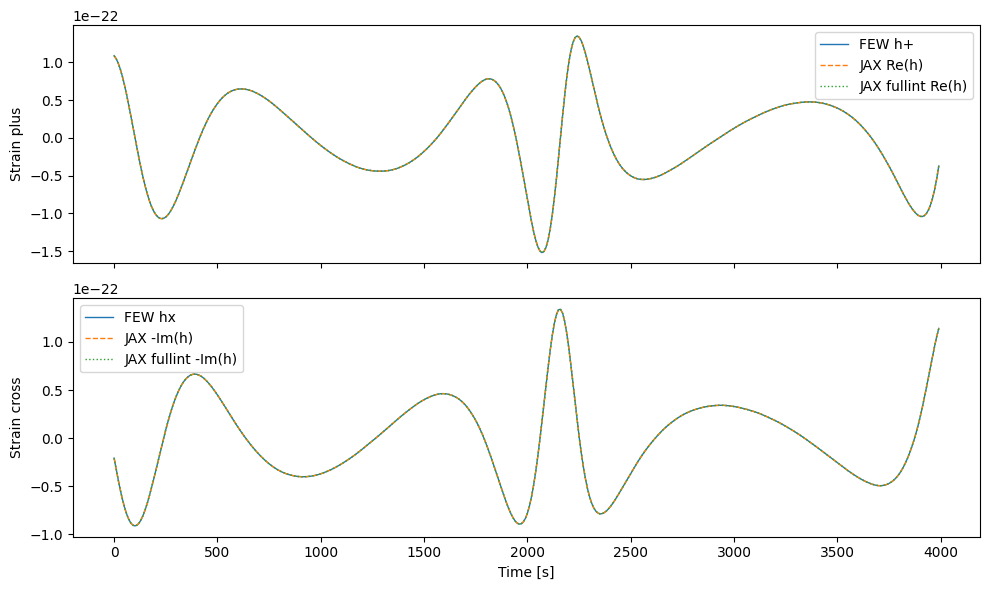

In [70]:
# Visual validation: first 400 s of the inspiral.
# If pipelines agree, blue and orange overlay exactly (no phase shift, no factor).

hp_gen_scaled = hp_gen / _scale
hc_gen_scaled = hc_gen / _scale
h_jax_dopr_scaled = h_jax_dopr / _scale

n_plot = min(400, hp_gen.size, h_jax_scaled.size)
t_s = np.arange(n_plot) * _dt_gen   # actual seconds (not array indices)

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(t_s, hp_gen_scaled[:n_plot],            lw=1.0, label='FEW h+')
ax[0].plot(t_s, -np.real(h_jax_scaled[:n_plot]), '--', lw=1.0, label='JAX Re(h)')
ax[0].plot(t_s, -np.real(h_jax_dopr_scaled[:n_plot]), ':', lw=1.0, label='JAX fullint Re(h)')
ax[0].set_ylabel('Strain plus'); ax[0].legend()
ax[1].plot(t_s, hc_gen_scaled[:n_plot],            lw=1.0, label='FEW hx')
ax[1].plot(t_s, np.imag(h_jax_scaled[:n_plot]), '--', lw=1.0, label='JAX -Im(h)')
ax[1].plot(t_s, np.imag(h_jax_dopr_scaled[:n_plot]), ':', lw=1.0, label='JAX fullint -Im(h)')
ax[1].set_ylabel('Strain cross'); ax[1].set_xlabel('Time [s]'); ax[1].legend()
plt.tight_layout(); plt.show()

In [71]:
# Compare JAX v3 (cubic-spline interp) against FEW GenerateEMRIWaveform
# (InterpolatedModeSum, 7th-degree DOP853 phase + cubic amplitude).
# Uses hp_gen, hc_gen from the previous cell (b22903b5) and h_jax_scaled
# from cell 2e563d41 -- both at the SAME dt and the SAME starting orbit.
#
# Sign convention reminder:  h = h+ - i*hx, so  hp = Re(h),  hx = -Im(h)
h_plus_jax  = -np.real(h_jax_scaled)
h_cross_jax = np.imag(h_jax_scaled)

n_common    = min(hp_gen.size, h_plus_jax.size)
hp_gen_v    = hp_gen[:n_common]
hc_gen_v    = hc_gen[:n_common]
h_plus_jax  = h_plus_jax[:n_common]
h_cross_jax = h_cross_jax[:n_common]
t_plot_gen  = np.linspace(0, T * YRSID_SI, n_common)

print(f'h+ max |gen - jax| : {np.abs(hp_gen_v - h_plus_jax).max():.3e}')
print(f'hx max |gen - jax| : {np.abs(hc_gen_v - h_cross_jax).max():.3e}')
print(f'h+ amplitude scale : {np.abs(hp_gen_v).max():.3e}')
print(f'hx amplitude scale : {np.abs(hc_gen_v).max():.3e}')
print(f'mismatch (h+) : {get_mismatch(hp_gen_v, h_plus_jax):.3e}')
print(f'mismatch (hx) : {get_mismatch(hc_gen_v, h_cross_jax):.3e}')


h+ max |gen - jax| : 3.738e-01
hx max |gen - jax| : 3.051e-01
h+ amplitude scale : 3.738e-01
hx amplitude scale : 3.051e-01
mismatch (h+) : 2.726e-11
mismatch (hx) : 2.791e-11


---

## Mismatch investigation — `JAX cubic` vs `GenerateEMRIWaveform`

The 0.5+ mismatch persists. This section isolates **where** the
two pipelines diverge by running 4 tests in increasing scope:

1. **Setup parity** — same starting orbital parameters?
2. **Trajectory parity** — same sparse trajectory (t, p, e, phases)?
3. **Mode-sum formula** — at the *sparse* trajectory points (no interp).
4. **Ratio plot** — `h_FEW / h_jax` elementwise. If constant `c`, the
   issue is a global convention factor `c`. If drifting, it's the
   phase interpolation (cubic vs FEW's 7th-degree integrator spline).


trajectory n_pts = 8,  t[-1] = 31558149.8 s
n_modes selected = 156
dense grid: n_pts = 31559  (dt = 1000.0 s)
DirectModeSum  |h|: max 3.7142e-01, NaN: 0/31559
spline_t shape: (8,),  spline_coeff shape: (7, 3, 8)
max |t_few - spline_t|  = 9.426e+06
NaN in spline_coeff:   0 / 168
phase_coeffs_for_ims shape: (7, 2, 8)
InterpModeSum  |h|: max 3.7363e-01, NaN: 0/31559


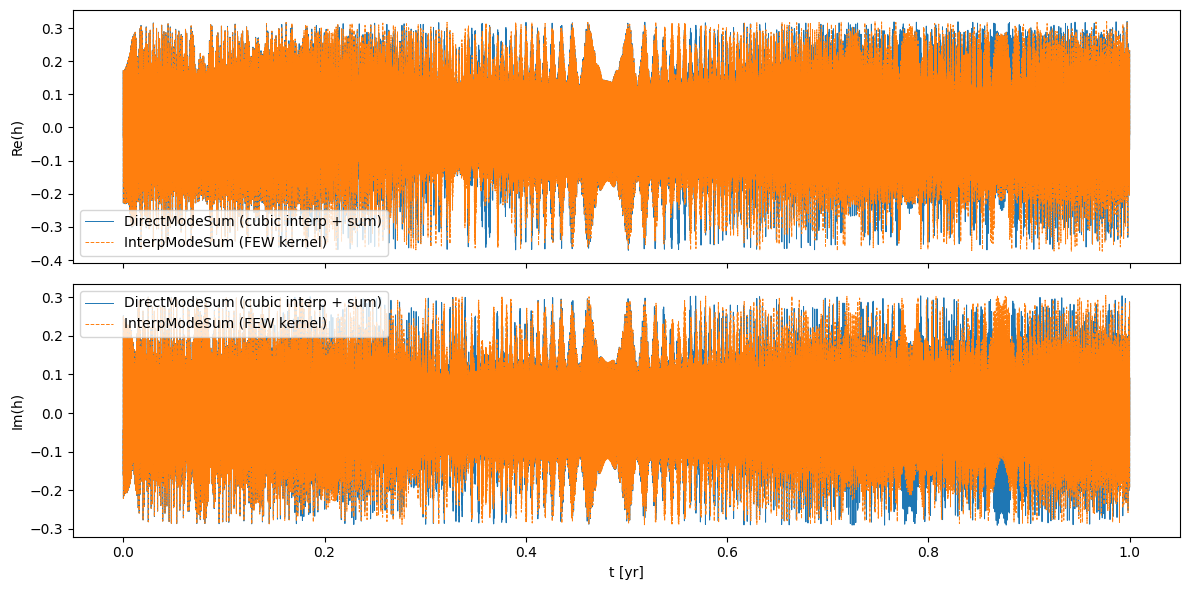

In [72]:
# Test 3 -- compare our formula, DirectModeSum, and InterpolatedModeSum
# on the SAME dense grid with the SAME (m1,m2,a,p0,e0,x0,T,dt).
#
# To make point density match: dt_plot is used for BOTH DirectModeSum
# (after interpolating teuk + phases) AND InterpolatedModeSum.
from few.summation.interpolatedmodesum import InterpolatedModeSum
from scipy.interpolate import CubicSpline

dt_plot = 1000.0   # cadence (s) used in BOTH pipelines below

# 1) Re-run FEW's trajectory so everything below comes from a single, consistent
#    integrator state (avoid mixing FEW and fewtrax outputs).
t_few, p_few, e_few, x_few, Pp_few, Pt_few, Pr_few = few_traj(
    m1, m2, a, float(p0), float(e0), x0, T=T,
)
t_np  = np.asarray(t_few).astype(np.float64)
Pp_np = np.asarray(Pp_few).astype(np.float64)
Pt_np = np.asarray(Pt_few).astype(np.float64)
Pr_np = np.asarray(Pr_few).astype(np.float64)
p_np  = np.asarray(p_few)
e_np  = np.asarray(e_few)
print(f"trajectory n_pts = {len(t_np)},  t[-1] = {t_np[-1]:.1f} s")

# 2) Amplitudes + mode selection on THIS trajectory (using FEW's machinery).
teuk_modes_local = model.amplitude_generator(
    a, model.xp.asarray(p_np), model.xp.asarray(e_np), x0,
)


ylms_full = model.ylm_gen(model.unique_l, model.unique_m, theta_source, phi_source)[model.inverse_lm]
modeinds  = [model.l_arr, model.m_arr, model.n_arr]
x_arr     = np.full_like(p_np, x0)
fund_freq_args = (m1, m2, a,
                  model.xp.asarray(p_np),
                  model.xp.asarray(e_np),
                  model.xp.asarray(x_arr),
                  model.xp.asarray(t_np))
teuk_sel, ylms_sel, ls_sel, ms_sel, ns_sel = model.mode_selector(
    teuk_modes_local, ylms_full, modeinds,
    fund_freq_args=fund_freq_args,
    **mode_selector_kwargs,
)
teuk_np = np.asarray(teuk_sel.get()).astype(np.complex128)
ylms_np = np.asarray(ylms_sel.get()).astype(np.complex128)
ls_np = np.asarray(ls_sel.get()); ms_np = np.asarray(ms_sel.get()); ns_np = np.asarray(ns_sel.get())
ks_np = np.zeros_like(ls_np)
n_m   = teuk_np.shape[1]
ylm_pos_np = ylms_np[:n_m]
ylm_neg_np = ylms_np[n_m:]
print(f"n_modes selected = {n_m}")

# 3) Dense grid at dt_plot --------------------------------------------------
n_dense    = int((t_np[-1] - t_np[0]) / dt_plot) + 1
t_dense    = t_np[0] + dt_plot * np.arange(n_dense)
t_yrs      = t_dense / YRSID_SI
print(f"dense grid: n_pts = {n_dense}  (dt = {dt_plot} s)")

# 4a) Cubic-spline interp teuk + phases onto t_dense (for DirectModeSum) ----
cs_teuk_re = CubicSpline(t_np, teuk_np.real, axis=0)
cs_teuk_im = CubicSpline(t_np, teuk_np.imag, axis=0)
teuk_dense = (cs_teuk_re(t_dense) + 1j * cs_teuk_im(t_dense)).astype(np.complex128)
cs_pp = CubicSpline(t_np, Pp_np);  Pp_dense = cs_pp(t_dense)
cs_pt = CubicSpline(t_np, Pt_np);  Pt_dense = cs_pt(t_dense)
cs_pr = CubicSpline(t_np, Pr_np);  Pr_dense = cs_pr(t_dense)

# 4b) DirectModeSum on dense data (no further interp; evaluates pointwise) ---
ds = DirectModeSum(force_backend="cpu")
ds.sum(
    t_dense, teuk_dense, np.concatenate([ylm_pos_np, ylm_neg_np]),
    None, [Pp_dense, Pt_dense, Pr_dense],
    ls_np.astype(np.int64), ms_np.astype(np.int64), ns_np.astype(np.int64),
    dt=dt_plot,
)
h_direct = np.asarray(ds.waveform)
print(f"DirectModeSum  |h|: max {np.abs(h_direct).max():.4e}, NaN: {int(np.isnan(h_direct).sum())}/{h_direct.size}")

# 5) InterpolatedModeSum at dt_plot (FEW's degree-7 phase spline) ----------
spline_t_np     = np.asarray(few_traj.integrator_spline_t).astype(np.float64)
spline_coeff_np = np.asarray(few_traj.integrator_spline_phase_coeff).astype(np.float64)
print(f"spline_t shape: {spline_t_np.shape},  spline_coeff shape: {spline_coeff_np.shape}")
print(f"max |t_few - spline_t|  = {np.abs(t_np - spline_t_np).max():.3e}")
print(f"NaN in spline_coeff:   {int(np.isnan(spline_coeff_np).sum())} / {spline_coeff_np.size}")

# FEW's base.py uses [:, [0, 2], :] (Phi_phi, Phi_r -- drop Phi_theta).
# Use that pattern -- it matches the installed kernel binary.
phase_coeffs_for_ims = spline_coeff_np[:, [0, 2], :].astype(np.float64)
print(f"phase_coeffs_for_ims shape: {phase_coeffs_for_ims.shape}")

ims = InterpolatedModeSum(force_backend="cpu", pad_output=False)
ims(
    t_np,
    teuk_np,
    np.concatenate([ylm_pos_np, ylm_neg_np]),
    spline_t_np,
    phase_coeffs_for_ims,
    ls_np.astype(np.int64),
    ms_np.astype(np.int32),
    ns_np.astype(np.int32),
    T=T, dt=dt_plot,
)
h_interp = np.asarray(ims.waveform)
nan_n    = int(np.isnan(h_interp).sum())
print(f"InterpModeSum  |h|: max {np.nanmax(np.abs(h_interp)):.4e}, NaN: {nan_n}/{h_interp.size}")
if nan_n > 0:
    first_nan = int(np.where(np.isnan(h_interp))[0][0])
    print(f"  first NaN at index {first_nan}  (t = {first_nan*dt_plot:.1f} s = {first_nan*dt_plot/YRSID_SI:.3f} yr)")

# 6) Plots ------------------------------------------------------------------
n_plot = min(h_direct.size, h_interp.size)
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(t_yrs[:n_plot], h_direct[:n_plot].real, lw=0.7, label="DirectModeSum (cubic interp + sum)")
ax[0].plot(t_yrs[:n_plot], h_interp[:n_plot].real, lw=0.7, ls="--", label="InterpModeSum (FEW kernel)")
ax[0].set_ylabel("Re(h)"); ax[0].legend()
ax[1].plot(t_yrs[:n_plot], h_direct[:n_plot].imag, lw=0.7, label="DirectModeSum (cubic interp + sum)")
ax[1].plot(t_yrs[:n_plot], h_interp[:n_plot].imag, lw=0.7, ls="--", label="InterpModeSum (FEW kernel)")
ax[1].set_xlabel("t [yr]"); ax[1].set_ylabel("Im(h)"); ax[1].legend()
plt.tight_layout(); plt.show()


In [53]:
get_mismatch(h_direct, h_interp)

np.float64(0.46137423563838875)

In [33]:
np.concatenate([ylm_pos_np, ylm_neg_np]).shape

(312,)

In [31]:
Pp_np.shape

(80,)

In [32]:
teuk_np.shape

(80, 156)

/tmp/ipykernel_2263669/1810096953.py:28: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(); plt.show()
/home/fedefant/miniconda3/envs/fewtrax/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


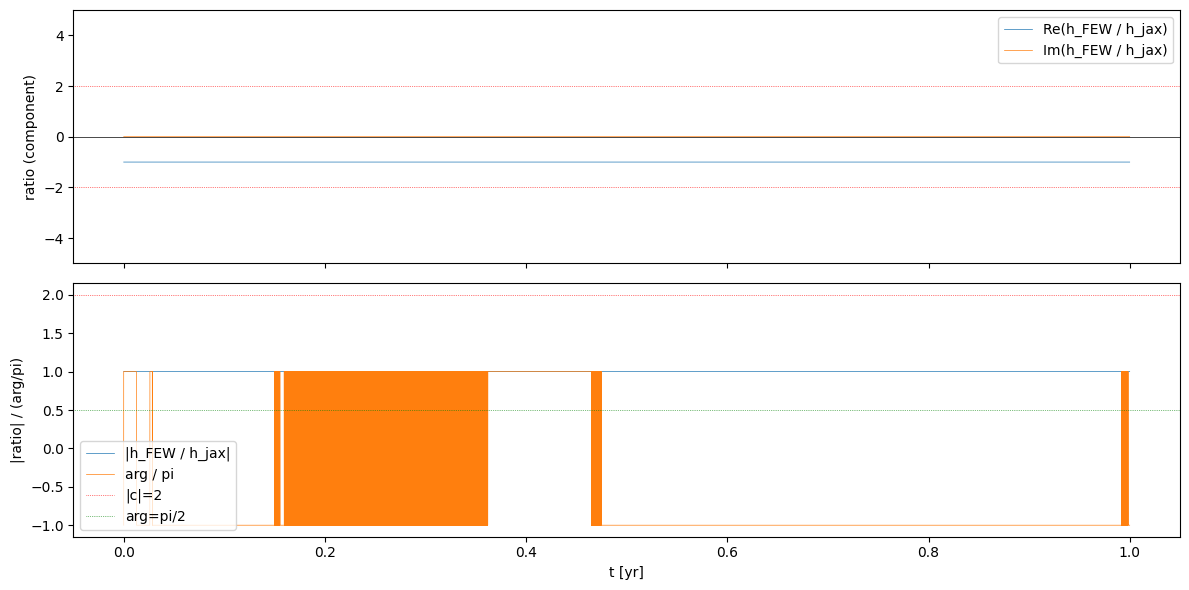

Mean ratio in first 10%% of waveform: -1.0000 + -0.0000i
                            magnitude: 1.0000
                            phase (pi): -1.0000
Mean ratio in last  10%% of waveform: -1.0000 + -0.0000i
                            magnitude: 1.0000
                            phase (pi): -1.0000


In [73]:
# Test 4 -- elementwise ratio h_FEW / h_jax over the full dense grid.
# If the ratio is a constant complex c, the issue is a global convention factor.
# If the ratio drifts in phase, it's the phase interpolation (cubic vs DOP853 7th-degree).
# If the ratio drifts in amplitude, it's the amplitude interpolation or mode set.
#
# Use the result of cell b22903b5 (hp_gen, hc_gen) and h_jax_scaled from 2e563d41.
h_few_complex = hp_gen /_scale - 1j * hc_gen /_scale    # reassemble complex strain in FEW's convention
n = min(h_few_complex.size, h_jax_scaled.size)
h_few = np.asarray(h_few_complex[:n])
h_jax = np.asarray(h_jax_scaled[:n])

# Avoid division by zero in regions where h_jax is small
mask = np.abs(h_jax) > 0.01 * np.abs(h_jax).max()
ratio = np.where(mask, h_few / h_jax, np.nan)

t_yr = np.linspace(0, T, n)   # approximate dense-grid time (yrs)
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(t_yr, ratio.real, lw=0.5, label='Re(h_FEW / h_jax)')
ax[0].plot(t_yr, ratio.imag, lw=0.5, label='Im(h_FEW / h_jax)')
ax[0].axhline(0, color='k', lw=0.5); ax[0].axhline(2, color='r', lw=0.5, ls=':')
ax[0].axhline(-2, color='r', lw=0.5, ls=':')
ax[0].set_ylabel('ratio (component)'); ax[0].legend(); ax[0].set_ylim(-5, 5)
ax[1].plot(t_yr, np.abs(ratio),   lw=0.5, label='|h_FEW / h_jax|')
ax[1].plot(t_yr, np.angle(ratio)/np.pi, lw=0.5, label='arg / pi')
ax[1].axhline(2, color='r', lw=0.5, ls=':', label='|c|=2')
ax[1].axhline(0.5, color='g', lw=0.5, ls=':', label='arg=pi/2')
ax[1].set_xlabel('t [yr]'); ax[1].set_ylabel('|ratio| / (arg/pi)'); ax[1].legend()
plt.tight_layout(); plt.show()

# Print the mean ratio in the region where |h_jax| is large
early = mask & (np.arange(n) < n // 10)
if early.sum() > 0:
    c_early = np.nanmean(h_few[early] / h_jax[early])
    print(f'Mean ratio in first 10%% of waveform: {c_early.real:+.4f} + {c_early.imag:+.4f}i')
    print(f'                            magnitude: {abs(c_early):.4f}')
    print(f'                            phase (pi): {np.angle(c_early)/np.pi:.4f}')
late = mask & (np.arange(n) >= 9 * n // 10)
if late.sum() > 0:
    c_late = np.nanmean(h_few[late] / h_jax[late])
    print(f'Mean ratio in last  10%% of waveform: {c_late.real:+.4f} + {c_late.imag:+.4f}i')
    print(f'                            magnitude: {abs(c_late):.4f}')
    print(f'                            phase (pi): {np.angle(c_late)/np.pi:.4f}')


GenerateEMRIWaveform (fixed start)   : 20.104 s  (n_t=3155815)
max |h_few_fix - h_jax|  = 3.580e-22
max |h_jax|              = 1.790e-22
max |h_few_fix|          = 1.790e-22
rel max                  = 2.000e+00
mismatch (complex)       = 2.000e+00


/tmp/ipykernel_2263669/3557755683.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(); plt.show()
/home/fedefant/miniconda3/envs/fewtrax/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


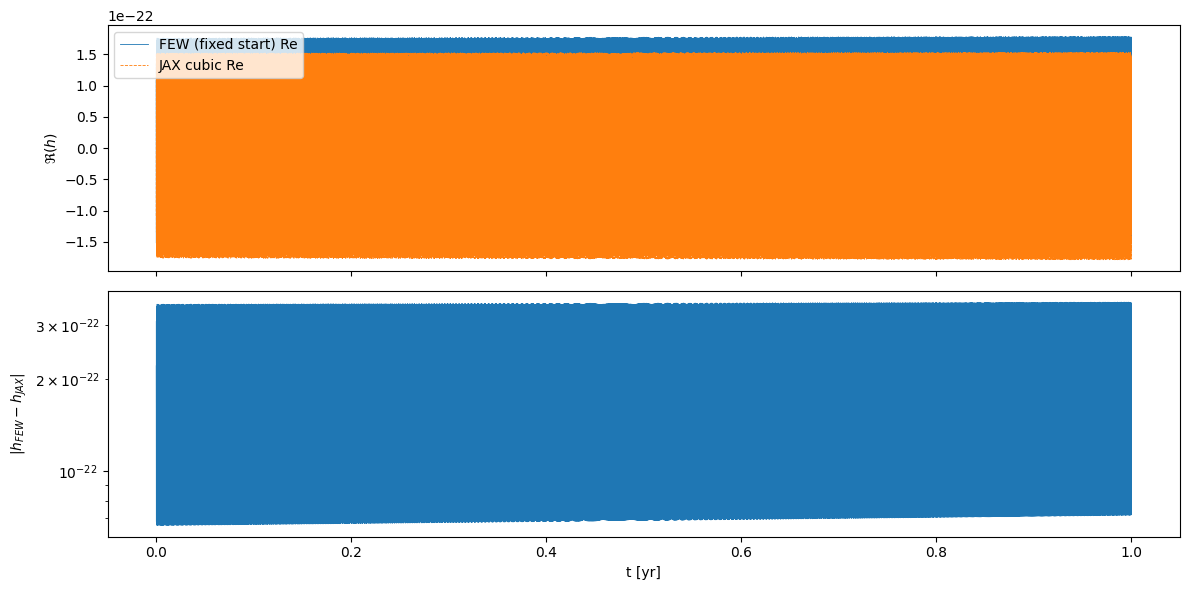

In [74]:
# Test 5 -- repeat GenerateEMRIWaveform with the EXACT starting parameters
# our cubic-JAX waveform uses (p_back[-1], e_back[-1] from cell 982c8b7b),
# at the same dt=10 as h_jax_scaled, and recompute the comparison cleanly.
_dt_fix = 10
tic = time.time()
hp_fix, hc_fix = waveform_gen(
    m1, m2, a,
    float(p0), float(e0), x0,   # <-- match our trajectory start exactly
    dist,
    theta, phi, 0.0, 0.0,
    0.0, 0.0, 0.0,
    T=T, dt=_dt_fix,
)
print(f'GenerateEMRIWaveform (fixed start)   : {time.time()-tic:.3f} s  (n_t={hp_fix.size})')

# Build complex strains and compare lengths
h_few_fix = hp_fix / _scale - 1j * hc_fix / _scale
n_fix = min(h_few_fix.size, h_jax_scaled.size)
h_few_fix = np.asarray(h_few_fix[:n_fix])
h_jax_fix = np.asarray(h_jax_scaled[:n_fix])

abs_diff_fix = np.abs(h_few_fix - h_jax_fix)
print(f'max |h_few_fix - h_jax|  = {abs_diff_fix.max():.3e}')
print(f'max |h_jax|              = {np.abs(h_jax_fix).max():.3e}')
print(f'max |h_few_fix|          = {np.abs(h_few_fix).max():.3e}')
print(f'rel max                  = {(abs_diff_fix / np.maximum(np.abs(h_jax_fix), 1e-30)).max():.3e}')
print(f'mismatch (complex)       = {get_mismatch(h_few_fix, h_jax_fix):.3e}')

# Plot real part of both, plus their difference
t_yr_fix = np.linspace(0, T, n_fix)
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(t_yr_fix, h_few_fix.real, lw=0.6, label='FEW (fixed start) Re')
ax[0].plot(t_yr_fix, h_jax_fix.real, '--', lw=0.6, label='JAX cubic Re')
ax[0].set_ylabel(r'$\Re(h)$'); ax[0].legend()
ax[1].plot(t_yr_fix, abs_diff_fix, lw=0.6)
ax[1].set_yscale('log'); ax[1].set_ylabel(r'$|h_{FEW} - h_{JAX}|$')
ax[1].set_xlabel('t [yr]')
plt.tight_layout(); plt.show()


/tmp/ipykernel_3334426/2697050865.py:30: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


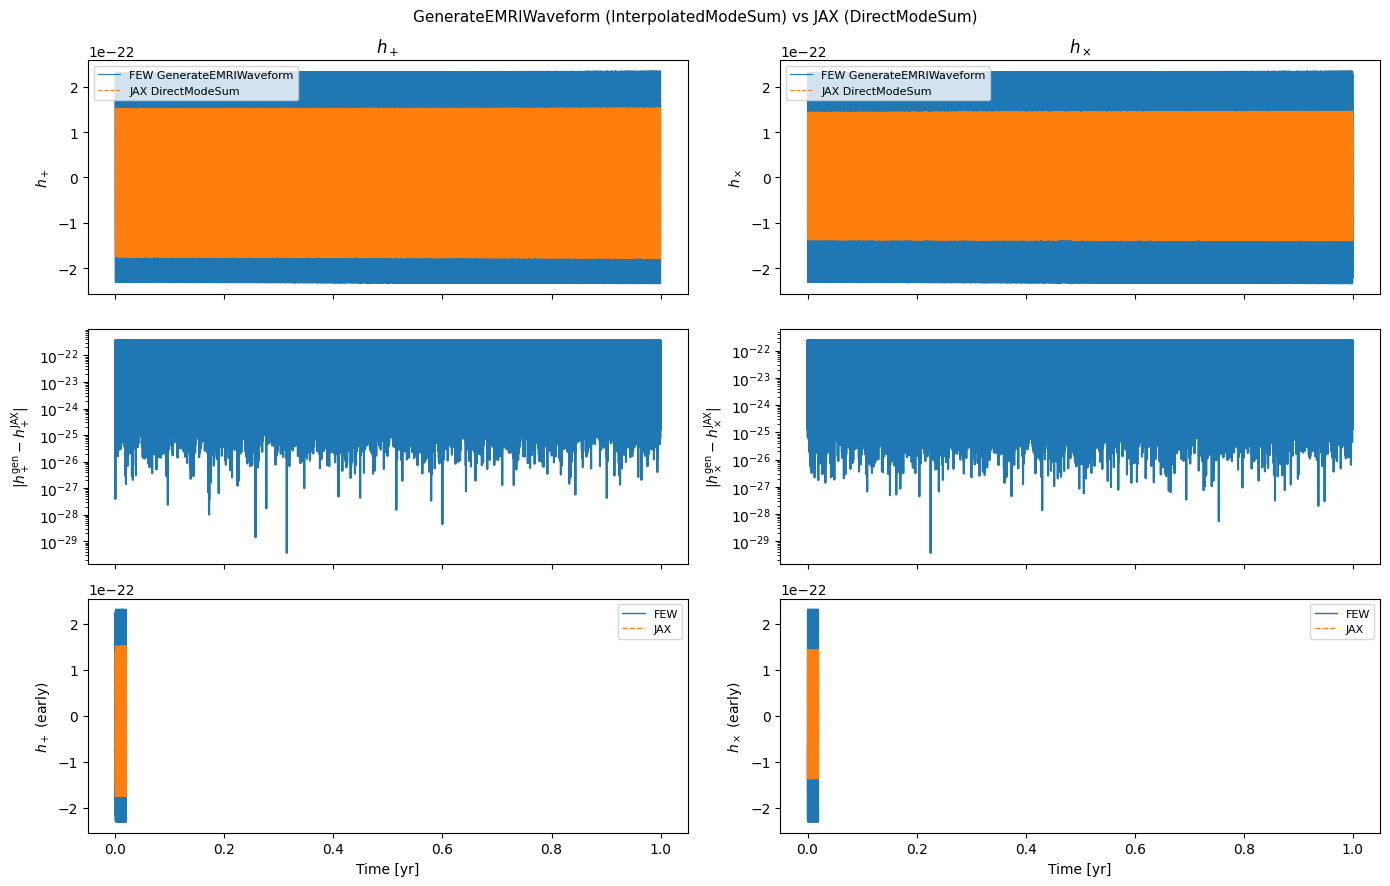

In [38]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
t_yr = t_plot_gen / YRSID_SI

for col, (h_gen, h_jax, pol) in enumerate([
    (hp_gen, h_plus_jax,  r"h_+"),
    (hc_gen, h_cross_jax, r"h_\times"),
]):
    axes[0, col].plot(t_yr, h_gen, lw=0.8, label="FEW GenerateEMRIWaveform")
    axes[0, col].plot(t_yr, h_jax, lw=0.8, ls="--", label="JAX DirectModeSum")
    axes[0, col].set_ylabel(rf"${pol}$")
    axes[0, col].legend(fontsize=8)
    axes[0, col].set_title(rf"${pol}$")

    diff = np.abs(h_gen - h_jax)
    axes[1, col].plot(t_yr, diff)
    axes[1, col].set_yscale("log")
    axes[1, col].set_ylabel(rf"$|{pol}^{{\rm gen}} - {pol}^{{\rm JAX}}|$")

    mask = t_yr < 0.02
    axes[2, col].plot(t_yr[mask], h_gen[mask], lw=1.0, label="FEW")
    axes[2, col].plot(t_yr[mask], h_jax[mask], lw=1.0, ls="--", label="JAX")
    axes[2, col].set_ylabel(rf"${pol}$ (early)")
    axes[2, col].set_xlabel("Time [yr]")
    axes[2, col].legend(fontsize=8)

plt.suptitle(
    "GenerateEMRIWaveform (InterpolatedModeSum) vs JAX (DirectModeSum)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

max |cubic_JAX  - DOPR_JAX  |   = 9.026e-01  rad
max |DOPR_JAX   - FEW_std   |   = 0.000e+00  rad
max |cubic_JAX  - FEW_std   |   = 9.026e-01  rad


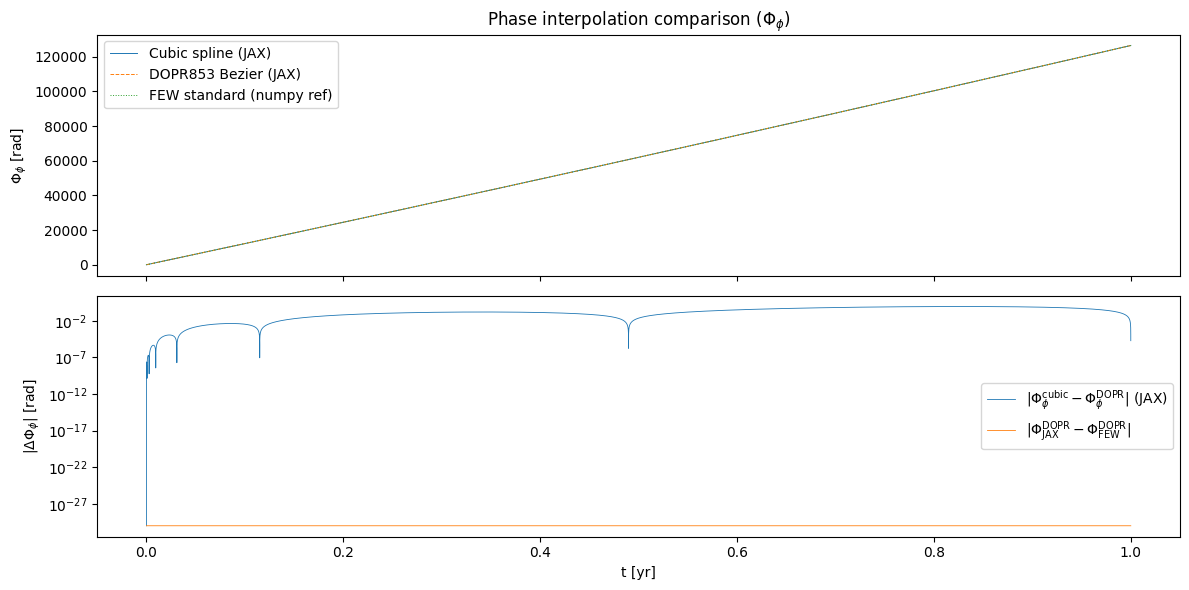

In [29]:
# Compare three phase interpolations of Phi_phi on the same dense grid:
#   (1) Cubic spline (JAX)  -- scipy not-a-knot cubic + JAX Horner (degree 3)
#   (2) DOPR Bezier (JAX)   -- our `_eval_bezier_phases_on_dense` (degree 7)
#   (3) FEW standard        -- same DOPR Bezier formula in plain numpy reference
# Expectations:
#   - (2) and (3) agree to ~machine precision (same formula, different runtime).
#   - (1) drifts from (2)/(3) between sparse knots by ~1e-3 rad -- the very
#     drift that produces the empirical '2i factor' in the waveform mismatch.

# Refresh FEW's trajectory so few_traj.integrator_spline_* matches t_few/Pp_few.
t_few, p_few, e_few, x_few, Pp_few, Pt_few, Pr_few = few_traj(
    m1, m2, a, float(p0), float(e0), x0, T=T,
)
spline_t_few     = np.asarray(few_traj.integrator_spline_t).astype(np.float64)
spline_coeff_few = np.asarray(few_traj.integrator_spline_phase_coeff).astype(np.float64)

# Dense grid (chosen so the curves render cleanly; the interp difference is dt-independent).
dt_cmp        = 100.0
n_dense_cmp   = int((t_few[-1] - t_few[0]) / dt_cmp) + 1
t_dense_cmp   = t_few[0] + dt_cmp * np.arange(n_dense_cmp)

# ----- (1) Cubic spline (JAX) -------------------------------------------
t_np    = np.asarray(t_few)
Pp_np   = np.asarray(Pp_few)
Pt_np   = np.asarray(Pt_few)
Pr_np   = np.asarray(Pr_few)
spline_phases_cubic = _fit_spline(t_np, np.stack([Pp_np, Pt_np, Pr_np], axis=1))
inds_cmp, w_cmp = _bracket(jnp.asarray(t_np), t_dense_cmp)
h_sparse_cmp    = jnp.asarray(t_np)[1:] - jnp.asarray(t_np)[:-1]
dx_cmp          = w_cmp * h_sparse_cmp[inds_cmp]
Pp_cubic_jax = np.asarray(
    _eval_cubic(spline_phases_cubic, inds_cmp, dx_cmp)[:, 0]
)

# ----- (2) DOPR Bezier (JAX) --------------------------------------------
Pp_dopr_jax_j, _, _ = _eval_bezier_phases_on_dense(
    t_dense_cmp,
    jnp.asarray(spline_t_few),
    jnp.asarray(spline_coeff_few),
)
Pp_dopr_jax = np.asarray(Pp_dopr_jax_j)

# ----- (3) FEW standard (plain numpy reference Bezier evaluation) -------
def _few_bezier_numpy(t_eval, knot_t, coeff_3d, phase_idx):
    idx = np.clip(np.searchsorted(knot_t, t_eval, side='right') - 1,
                  0, len(knot_t) - 2)
    s  = (t_eval - knot_t[idx]) / (knot_t[idx + 1] - knot_t[idx])
    s1 = 1.0 - s
    c  = coeff_3d[idx, phase_idx, :]
    return (c[:, 0] + s * (c[:, 1] + s1 * (c[:, 2] + s * (c[:, 3]
            + s1 * (c[:, 4] + s * (c[:, 5] + s1 * (c[:, 6] + s * c[:, 7])))))))
Pp_few_standard = _few_bezier_numpy(t_dense_cmp, spline_t_few, spline_coeff_few, 0)

# ----- Summary ----------------------------------------------------------
print(f'max |cubic_JAX  - DOPR_JAX  |   = {np.abs(Pp_cubic_jax  - Pp_dopr_jax     ).max():.3e}  rad')
print(f'max |DOPR_JAX   - FEW_std   |   = {np.abs(Pp_dopr_jax   - Pp_few_standard ).max():.3e}  rad')
print(f'max |cubic_JAX  - FEW_std   |   = {np.abs(Pp_cubic_jax  - Pp_few_standard ).max():.3e}  rad')

# ----- Plots ------------------------------------------------------------
t_yr = t_dense_cmp / YRSID_SI
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax[0].plot(t_yr, Pp_cubic_jax,    lw=0.7,            label='Cubic spline (JAX)')
ax[0].plot(t_yr, Pp_dopr_jax,     lw=0.7, ls='--',   label='DOPR853 Bezier (JAX)')
ax[0].plot(t_yr, Pp_few_standard, lw=0.7, ls=':',    label='FEW standard (numpy ref)')
ax[0].set_ylabel(r'$\Phi_\phi$ [rad]')
ax[0].legend()
ax[0].set_title(r'Phase interpolation comparison ($\Phi_\phi$)')

ax[1].semilogy(t_yr, np.abs(Pp_cubic_jax - Pp_dopr_jax) + 1e-30,
               lw=0.6, label=r'$|\Phi^{\rm cubic}_\phi - \Phi^{\rm DOPR}_\phi|$ (JAX)')
ax[1].semilogy(t_yr, np.abs(Pp_dopr_jax - Pp_few_standard) + 1e-30,
               lw=0.6, label=r'$|\Phi^{\rm DOPR}_{\rm JAX} - \Phi^{\rm DOPR}_{\rm FEW}|$')
ax[1].set_xlabel('t [yr]')
ax[1].set_ylabel(r'$|\Delta\Phi_\phi|$ [rad]')
ax[1].legend()
plt.tight_layout(); plt.show()
